# Week 1 · Exercise 1.3 — Toolbox shakedown

🚀 **Builder.** Python 3 + JupyterLab + NetworkX are already in this workspace (`uv`, `.venv`). This notebook is the rest of 1.3: Karate Club, a hand check, then a coded version of the adjacency-matrix explorable from Part 2.

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline

## Karate Club

Zachary's Karate Club is built into NetworkX. Nodes are members; edges are documented ties outside the club. The graph is undirected and unweighted.

nodes n = 34
edges m = 78
five highest-degree nodes:
  node 33: degree 17
  node 0: degree 16
  node 32: degree 12
  node 2: degree 10
  node 1: degree 9


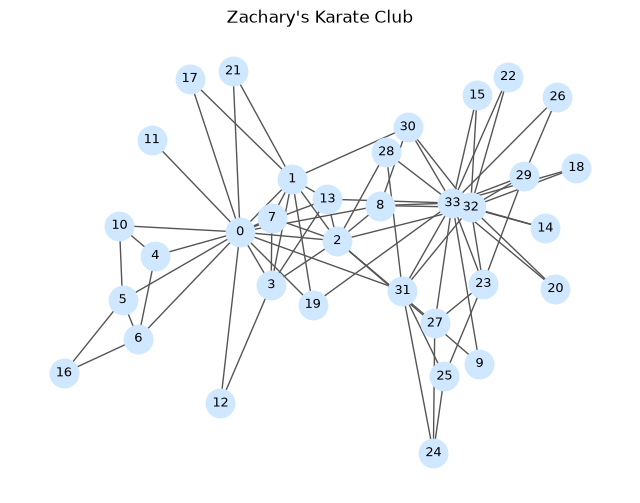

In [4]:
G = nx.karate_club_graph()

n = G.number_of_nodes()
m = G.number_of_edges()
top5 = sorted(G.degree(), key=lambda item: item[1], reverse=True)[:5]

print(f"nodes n = {n}")
print(f"edges m = {m}")
print("five highest-degree nodes:")
for node, degree in top5:
    print(f"  node {node}: degree {degree}")

pos = nx.spring_layout(G, seed=7)
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    ax=ax,
    node_color="#cfe8ff",
    edge_color="#555555",
    node_size=420,
    font_size=9,
    with_labels=True,
)
ax.set_title("Zachary's Karate Club")
ax.axis("off")
plt.show()

## Hand check (the part that matters)

Pick **node 11**: it is a leaf, so you can count its edges on the drawing without a hairball. NetworkX reports `degree(11) = 1` and neighbour `{0}`. On the figure, node 11 should have exactly one line, ending at node 0. If that count matches, the degree list is at least not inventing edges for this node.

**Three sentences.** The agent loaded the built-in graph, labelled every node, and printed `n`, `m`, and the top five degrees in one place, which makes the drawing checkable. It chose a degree-1 node for the hand count; if it had only drawn a force layout of the hubs, a wrong `degree()` would have been hard to catch by eye. What I would not have caught without counting: a silently dropped isolate, or a top-5 list that used 1-based labels while the drawing used 0-based ones.

In [5]:
check_node = 11
print(f"node {check_node} degree = {G.degree(check_node)}")
print(f"neighbours = {sorted(G.neighbors(check_node))}")
print("hand check: count the edges leaving 11 on the drawing above; it should be 1, to node 0.")

node 11 degree = 1
neighbours = [0]
hand check: count the edges leaving 11 on the drawing above; it should be 1, to node 0.


## Adjacency-matrix explorable, as code

A 6×6 directed matrix typed in by hand. Rows are *from*, columns are *to*. Node **F** is an isolate (empty row and column), matching Part 2's empty node H.

node | row sum (out) | NX out_degree | col sum (in) | NX in_degree
  A  |             2 |             2 |            1 |            1
  B  |             1 |             1 |            1 |            1
  C  |             1 |             1 |            2 |            2
  D  |             2 |             2 |            1 |            1
  E  |             0 |             0 |            1 |            1
  F  |             0 |             0 |            0 |            0
row/column sums agree with NetworkX in- and out-degree.


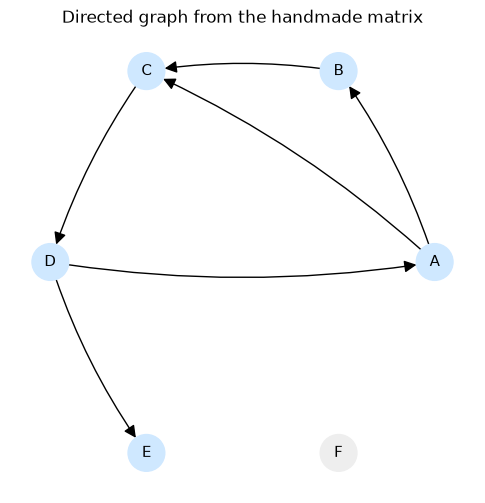

In [11]:
labels = ["A", "B", "C", "D", "E", "F"]

#        A  B  C  D  E  F
A = np.array(
    [
        [0, 1, 1, 0, 0, 0],  # A → B, A → C
        [0, 0, 1, 0, 0, 0],  # B → C
        [0, 0, 0, 1, 0, 0],  # C → D
        [1, 0, 0, 0, 1, 0],  # D → A, D → E
        [0, 0, 0, 0, 0, 0],  # E: no out-edges
        [0, 0, 0, 0, 0, 0],  # F: isolate
    ],
    dtype=float,
)

D = nx.from_numpy_array(A, create_using=nx.DiGraph)
D = nx.relabel_nodes(D, dict(enumerate(labels)))

row_sums = A.sum(axis=1)
col_sums = A.sum(axis=0)
out_deg = [D.out_degree(lab) for lab in labels]
in_deg = [D.in_degree(lab) for lab in labels]

print("node | row sum (out) | NX out_degree | col sum (in) | NX in_degree")
for i, lab in enumerate(labels):
    print(
        f"  {lab}  | {row_sums[i]:13.0f} | {out_deg[i]:13d} | {col_sums[i]:12.0f} | {in_deg[i]:12d}"
    )

assert np.array_equal(row_sums, out_deg), "row sums must match out-degree"
assert np.array_equal(col_sums, in_deg), "column sums must match in-degree"
print("row/column sums agree with NetworkX in- and out-degree.")

pos_dir = nx.circular_layout(D)
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx(
    D,
    pos=pos_dir,
    ax=ax,
    arrows=True,
    arrowsize=18,
    node_color=["#eeeeee" if lab == "F" else "#cfe8ff" for lab in D.nodes],
    node_size=700,
    font_size=11,
    connectionstyle="arc3,rad=0.08",
)
ax.set_title("Directed graph from the handmade matrix")
ax.axis("off")
plt.show()

### Symmetrise: $A + A^{\mathsf T}$, clipped to 1

An undirected network is a symmetric matrix; arrowheads should disappear.

symmetrised matrix:
[[0 1 1 1 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [1 0 1 0 1 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 0]]
undirected m = 6 (F still an isolate: degree 0)


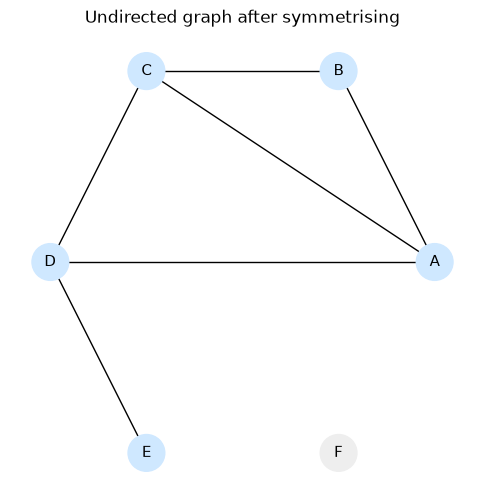

In [12]:
A_sym = np.clip(A + A.T, 0, 1)
np.fill_diagonal(A_sym, 0)  # simple undirected: no self-loops from the sum

U = nx.from_numpy_array(A_sym, create_using=nx.Graph)
U = nx.relabel_nodes(U, dict(enumerate(labels)))

print("symmetrised matrix:")
print(A_sym.astype(int))
print(f"undirected m = {U.number_of_edges()} (F still an isolate: degree {U.degree('F')})")

fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx(
    U,
    pos=pos_dir,
    ax=ax,
    arrows=False,
    node_color=["#eeeeee" if lab == "F" else "#cfe8ff" for lab in U.nodes],
    node_size=700,
    font_size=11,
)
ax.set_title("Undirected graph after symmetrising")
ax.axis("off")
plt.show()

### Plant a weight, an isolate, and a self-loop

Part 2: an entry is an edge, its size is the weight (shown as a number on the edge), an empty row *and* column is an isolate, a diagonal 1 is a self-loop.

planted matrix:
[[0 3 1 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [1 0 0 1 1 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
A→B weight = 3.0
self-loops on D: 1 (nodes: ['D'])
F in-degree=0, out-degree=0 (isolate)


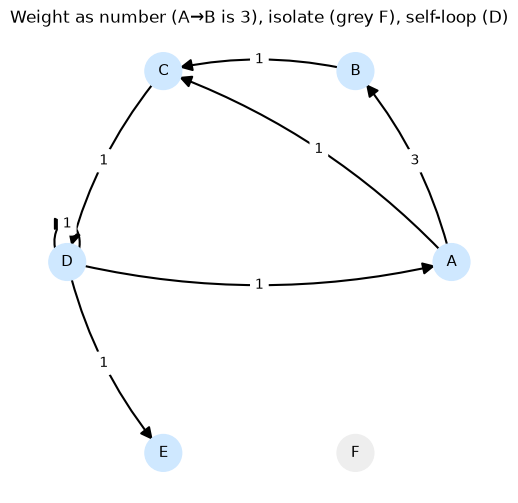

checks: weighted A→B, isolate F, self-loop on D all present.


In [16]:
A_planted = A.copy()
A_planted[0, 1] = 3  # A → B weight 3
A_planted[3, 3] = 1  # D → D self-loop
# F's row and column stay zero → isolate

P = nx.from_numpy_array(A_planted, create_using=nx.DiGraph)
P = nx.relabel_nodes(P, dict(enumerate(labels)))

print("planted matrix:")
print(A_planted.astype(int))
print(f"A→B weight = {P['A']['B']['weight']}")
print(f"self-loops on D: {nx.number_of_selfloops(P)} (nodes: {list(nx.nodes_with_selfloops(P))})")
print(f"F in-degree={P.in_degree('F')}, out-degree={P.out_degree('F')} (isolate)")

edge_labels = {(u, v): int(d["weight"]) for u, v, d in P.edges(data=True)}
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx_nodes(
    P,
    pos=pos_dir,
    ax=ax,
    node_color=["#eeeeee" if lab == "F" else "#cfe8ff" for lab in P.nodes],
    node_size=700,
)
nx.draw_networkx_labels(P, pos=pos_dir, ax=ax, font_size=11)
nx.draw_networkx_edges(
    P,
    pos=pos_dir,
    ax=ax,
    arrows=True,
    arrowsize=18,
    width=1.5,
    connectionstyle="arc3,rad=0.12",
    min_source_margin=12,
    min_target_margin=12,
)
nx.draw_networkx_edge_labels(
    P,
    pos=pos_dir,
    ax=ax,
    edge_labels=edge_labels,
    font_size=10,
    rotate=False,
    connectionstyle="arc3,rad=0.12",
)
ax.set_title("Weight as number (A→B is 3), isolate (grey F), self-loop (D)")
ax.axis("off")
plt.show()

assert P["A"]["B"]["weight"] == 3
assert P.in_degree("F") == 0 and P.out_degree("F") == 0
assert P.has_edge("D", "D")
print("checks: weighted A→B, isolate F, self-loop on D all present.")

# 1.4

1. Since the edges are wiki links, an in-link is others reference to a hero's wiki page. A big/famous wiki page is easy to reference. in-degree how much others treat this character as worth linking to; out-degree is how much this page itself links out.Therefore the in-links scale much easier and the out-link has the ceiling.

2. Isolates can have \(k = 0\); what is 0 or 1 in the tail is the *count of characters at that \(k\)* (one at 106, none at 105 or 107). Raw \(P(k)\) therefore looks like the power law dies around \(k \approx 20\). Binning does not invent the extra range: it averages neighbouring degrees so the trend that was already in those lonely 1’s becomes readable. A log axis cannot show the zeros, which is why the raw tail looks emptier than it is.

3. Not dividing by bin width makes larger bins better just because there is more data, not better data. Binning in dense data is not a good idea, because the binning here is not required and therefore the bins will throw away information by grouping the datapoints.

4. Only if they also have zero out-links. Someone nobody mentions but who links out a lot still has undirected k>0, so the low end mixes “obscure” with “silent.” The tail is in + out mashed together, so it is not “fame.” That is why you plot in and out separately.

# Exercise 1.6 — The distribution, as code

🚀 **Builder.** Rebuild the week-1 degree explorables. Nodes = Marvel character pages; edges = directed wiki-links in article text. Frozen snapshot from the [course data page](https://sunelehmann.com/socialgraphs2026-web/data).

In [17]:
from collections import Counter
from pathlib import Path

import pandas as pd

data_dir = Path("uge1") if Path("uge1/week1_nodes.tsv").exists() else Path(".")
nodes = pd.read_csv(
    data_dir / "week1_nodes.tsv", sep="\t", comment="#", quoting=3
)
edges = pd.read_csv(
    data_dir / "week1_edges.tsv",
    sep="\t",
    comment="#",
    names=["source", "target"],
)

Marvel = nx.DiGraph()
Marvel.add_nodes_from(nodes.node_id)
Marvel.add_edges_from(edges.itertuples(index=False))

n = Marvel.number_of_nodes()
m_dir = Marvel.number_of_edges()
n_isolates = sum(
    1 for v in Marvel if Marvel.in_degree(v) == 0 and Marvel.out_degree(v) == 0
)

U = Marvel.to_undirected()
m_und = U.number_of_edges()
k_bar = 2 * m_und / n

print(f"n = {n}  (page: 303)")
print(f"directed edges = {m_dir}  (page: 1784)")
print(f"isolates = {n_isolates}  (page: 17)")
print(f"undirected pairs m = {m_und}  (page: 1434)")
print(f"⟨k⟩ = 2m/n = {k_bar:.1f}  (page: ≈ 9.5)")
print(f"mean in-degree = {m_dir / n:.1f}, mean out-degree = {m_dir / n:.1f}")

assert n == 303 and m_dir == 1784 and n_isolates == 17
assert m_und == 1434
print("hand check: n, directed m, isolates, undirected m all match the week-1 page.")

n = 303  (page: 303)
directed edges = 1784  (page: 1784)
isolates = 17  (page: 17)
undirected pairs m = 1434  (page: 1434)
⟨k⟩ = 2m/n = 9.5  (page: ≈ 9.5)
mean in-degree = 5.9, mean out-degree = 5.9
hand check: n, directed m, isolates, undirected m all match the week-1 page.


The directed count is larger than the undirected pair count because **reciprocal links collapse**: 350 pairs link both ways, so \(1784 - 1434 = 350\). Each mutual pair is two directed edges but one undirected edge.

top 5 in-degree  (page: Spider-Man 106):
  Spider-Man  k = 106
  Hulk  k = 64
  Wolverine (character)  k = 60
  Doctor Strange  k = 50
  Deadpool  k = 33
top 5 out-degree  (page: Betsy Braddock 28):
  Betsy Braddock  k = 28
  Cloak and Dagger (characters)  k = 24
  Adam Warlock  k = 22
  Venom (character)  k = 21
  She-Hulk  k = 20


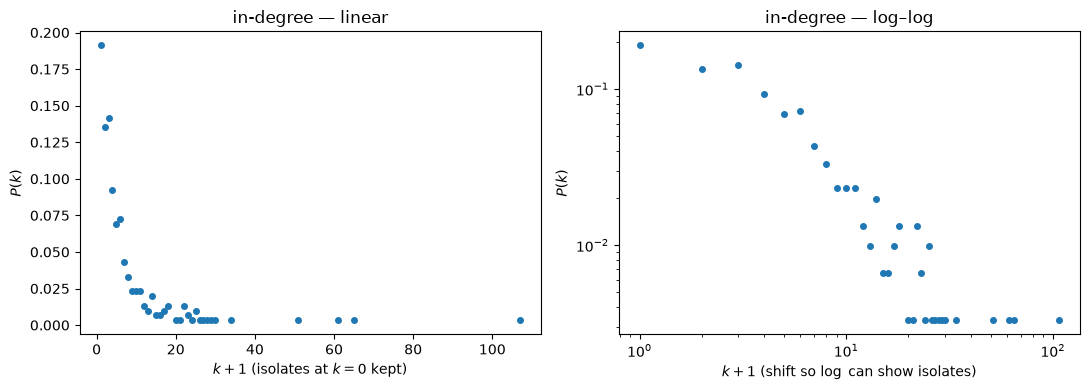

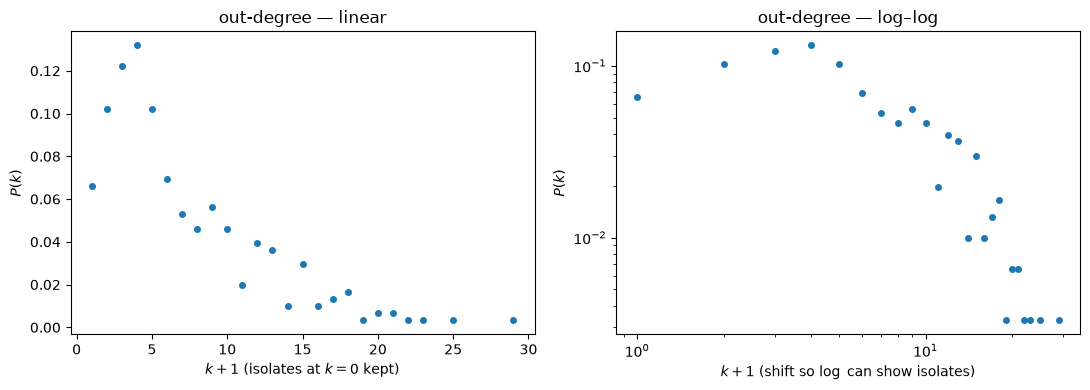

In [18]:
names = dict(zip(nodes.node_id, nodes.name))


def top5(degree_view, label):
    ranked = sorted(degree_view, key=lambda item: item[1], reverse=True)[:5]
    print(f"top 5 {label}:")
    for node, k in ranked:
        print(f"  {names[node]}  k = {k}")
    return ranked


top5(Marvel.in_degree(), "in-degree  (page: Spider-Man 106)")
top5(Marvel.out_degree(), "out-degree  (page: Betsy Braddock 28)")


def raw_pk(degree_sequence, n_nodes):
    counts = Counter(degree_sequence)
    k = np.array(sorted(counts))
    p = np.array([counts[ki] / n_nodes for ki in k])
    return k, p


def plot_raw_degrees(k, p, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(k + 1, p, "o", ms=4)
    axes[0].set_xlabel(r"$k+1$ (isolates at $k=0$ kept)")
    axes[0].set_ylabel(r"$P(k)$")
    axes[0].set_title(f"{title} — linear")

    axes[1].plot(k + 1, p, "o", ms=4)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel(r"$k+1$ (shift so $\log$ can show isolates)")
    axes[1].set_ylabel(r"$P(k)$")
    axes[1].set_title(f"{title} — log–log")
    fig.tight_layout()
    plt.show()


in_k, in_p = raw_pk([d for _, d in Marvel.in_degree()], n)
out_k, out_p = raw_pk([d for _, d in Marvel.out_degree()], n)
plot_raw_degrees(in_k, in_p, "in-degree")
plot_raw_degrees(out_k, out_p, "out-degree")

Official binning (Goodies): work in \(u = k+1\). Width-1 bins for \(u = 1,\ldots,7\), then doubling \([8,16)\), \([16,32)\), \([32,64)\), \([64,128)\). Plot \(n_{\mathrm{bin}} / (\mathrm{width} \cdot n)\). Wide bins sit at \(\sqrt{u_{\min} \cdot (u_{\max})}\) of the integers they cover.

in-degree + official bins: width-1 bins coincide with raw P(k).


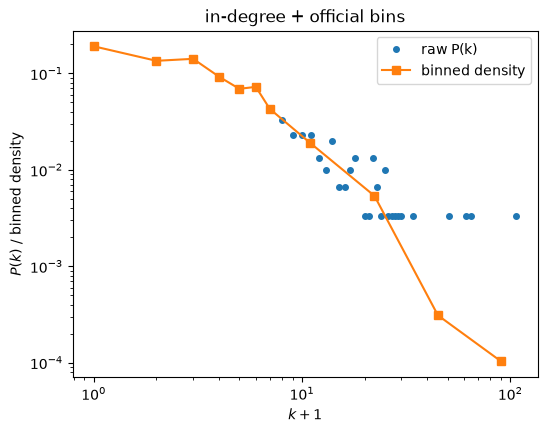

out-degree + official bins: width-1 bins coincide with raw P(k).


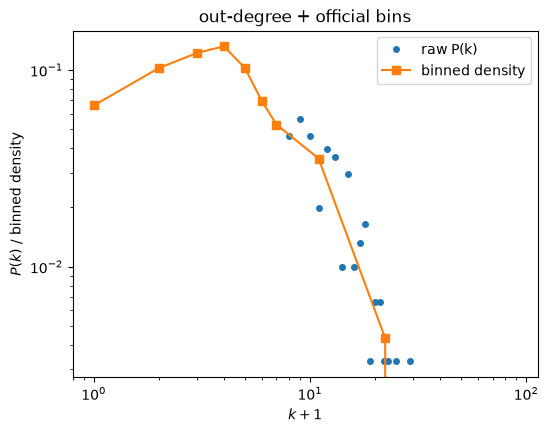

In [19]:
def official_binning(degree_sequence, n_nodes):
    u = np.asarray(degree_sequence) + 1
    xs, ys = [], []
    for ui in range(1, 8):
        count = np.sum(u == ui)
        xs.append(ui)
        ys.append(count / 1 / n_nodes)
    lo = 8
    while lo < 128:
        hi = lo * 2
        count = np.sum((u >= lo) & (u < hi))
        width = hi - lo
        xs.append(np.sqrt(lo * (hi - 1)))
        ys.append(count / width / n_nodes)
        lo = hi
    return np.array(xs), np.array(ys)


def overlay_binned(degree_sequence, title):
    k, p = raw_pk(degree_sequence, n)
    bx, by = official_binning(degree_sequence, n)
    # width-1 bins must sit on raw P(k)
    raw_low = {int(ki + 1): pi for ki, pi in zip(k, p) if ki <= 6}
    for ui, yi in zip(bx[:7], by[:7]):
        if ui in raw_low:
            assert np.isclose(yi, raw_low[ui]), f"width-1 mismatch at u={ui}"
    print(f"{title}: width-1 bins coincide with raw P(k).")

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.loglog(k + 1, p, "o", ms=4, label="raw P(k)")
    ax.loglog(bx, by, "s-", ms=6, label="binned density")
    ax.set_xlabel(r"$k+1$")
    ax.set_ylabel(r"$P(k)$ / binned density")
    ax.set_title(title)
    ax.legend()
    plt.show()


overlay_binned([d for _, d in Marvel.in_degree()], "in-degree + official bins")
overlay_binned([d for _, d in Marvel.out_degree()], "out-degree + official bins")

Exponential \(p(x) \propto e^{-x/\lambda}\) is a straight line on **log-\(y\), linear-\(x\)**. Power law \(p(x) \propto x^{-\alpha}\) is a straight line on **log–log**. Inverse-CDF samples below: exponential with mean \(\lambda = 5.9\) (Marvel’s mean degree) and Pareto/power-law with \(x_{\min}=1\), \(\alpha=2.5\).

exponential:  x = -λ log(U)   via rng.exponential(scale=λ)
power law:    x = xmin * U**(-1/(α-1))   (Pareto / Zipf-continuous)


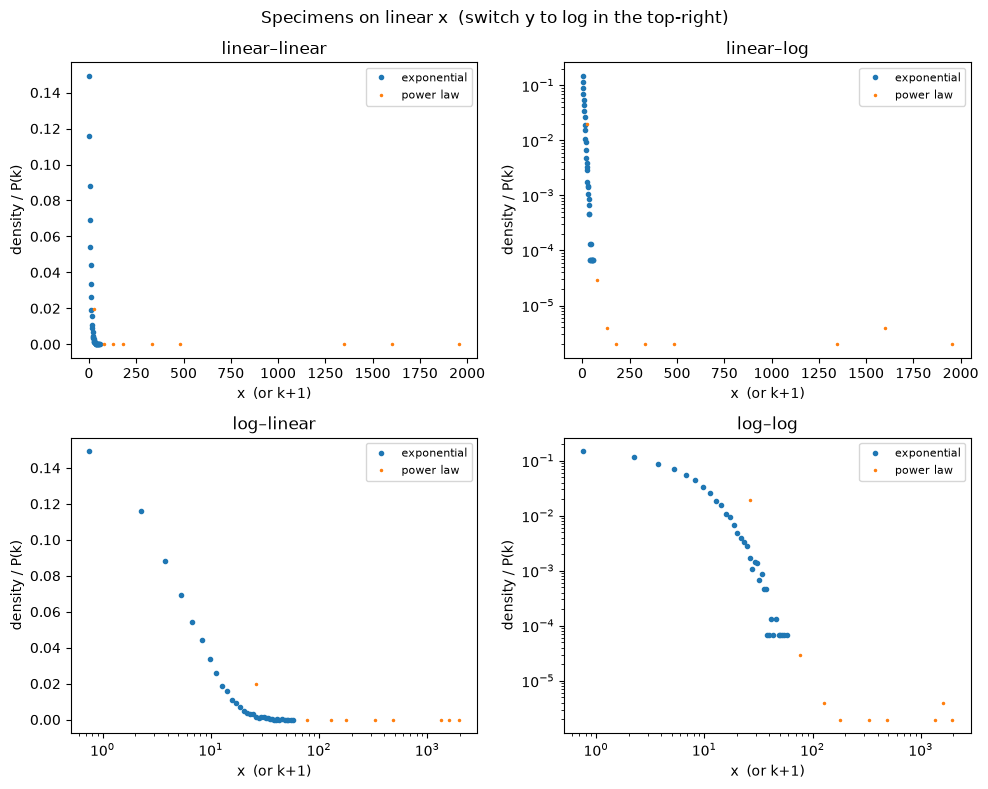

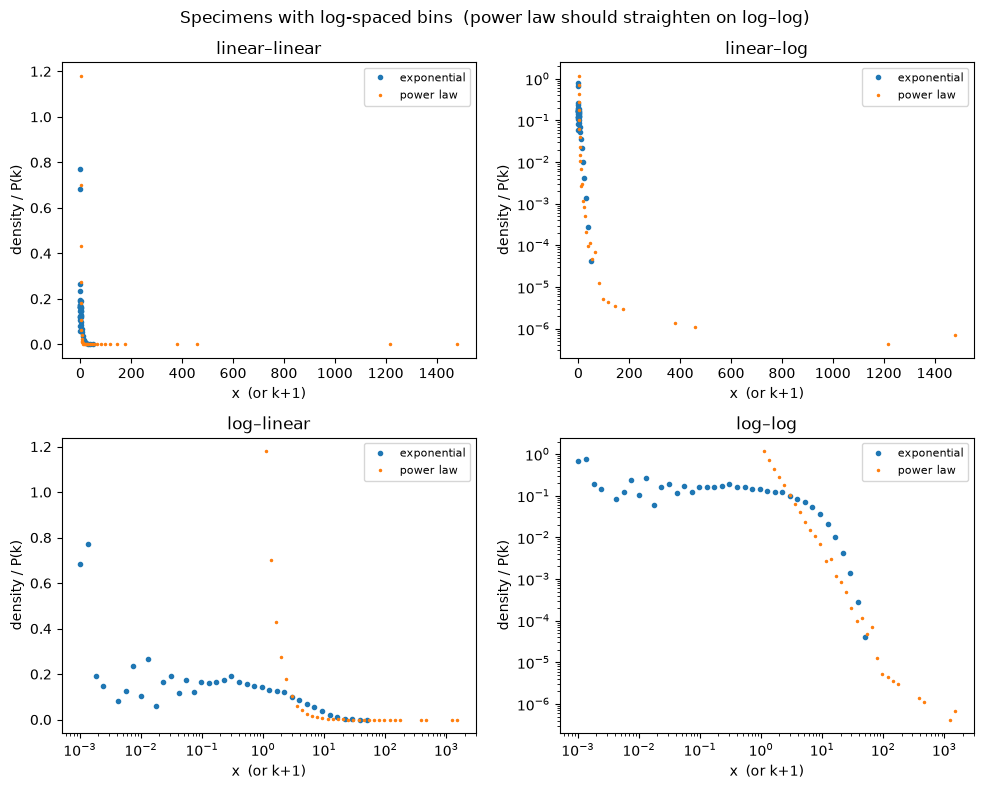

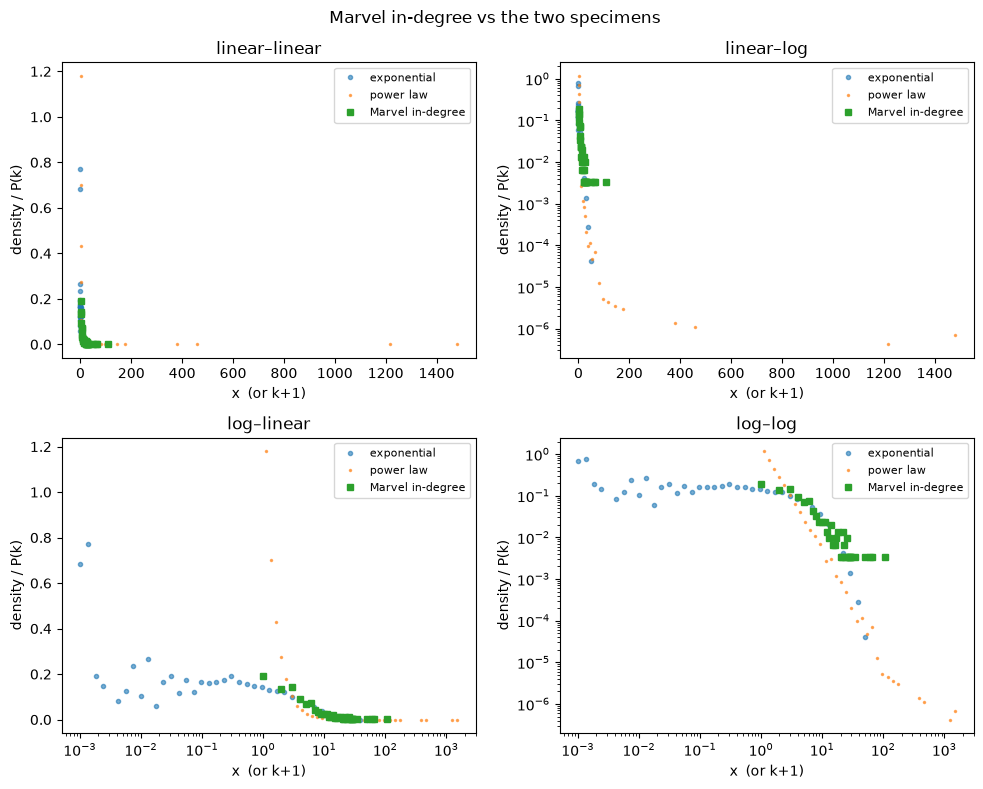

By eye: Marvel in-degree follows the power-law specimen on log–log much more than the exponential (which bends). Week 2 treats this properly; do not read a slope off this plot.


In [20]:
rng = np.random.default_rng(1)
n_samp = 10_000
lam = 5.9
alpha = 2.5
xmin = 1.0

exp_samples = rng.exponential(scale=lam, size=n_samp)
# Inverse CDF of Pareto: X = xmin * U^{-1/(alpha-1)}
pl_samples = xmin * rng.random(n_samp) ** (-1 / (alpha - 1))

print("exponential:  x = -λ log(U)   via rng.exponential(scale=λ)")
print("power law:    x = xmin * U**(-1/(α-1))   (Pareto / Zipf-continuous)")


def hist_pdf(samples, log_x=False, n_bins=40):
    samples = np.asarray(samples)
    samples = samples[samples > 0]
    if log_x:
        edges = np.logspace(np.log10(samples.min()), np.log10(samples.max()), n_bins)
        centers = np.sqrt(edges[:-1] * edges[1:])
    else:
        edges = np.linspace(samples.min(), samples.max(), n_bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
    dens, _ = np.histogram(samples, bins=edges, density=True)
    mask = dens > 0
    return centers[mask], dens[mask]


def four_axis_plot(series, labels, title):
    """series: list of (x, y, style_dict) drawn on all four scale combos."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    configs = [
        (axes[0, 0], False, False, "linear–linear"),
        (axes[0, 1], False, True, "linear–log"),
        (axes[1, 0], True, False, "log–linear"),
        (axes[1, 1], True, True, "log–log"),
    ]
    for ax, logx, logy, name in configs:
        for x, y, kw in series:
            ax.plot(x, y, **kw)
        if logx:
            ax.set_xscale("log")
        if logy:
            ax.set_yscale("log")
        ax.set_title(name)
        ax.set_xlabel("x  (or k+1)")
        ax.set_ylabel("density / P(k)")
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


exp_lin = hist_pdf(exp_samples, log_x=False)
exp_log = hist_pdf(exp_samples, log_x=True)
pl_lin = hist_pdf(pl_samples, log_x=False)
pl_log = hist_pdf(pl_samples, log_x=True)

four_axis_plot(
    [
        (exp_lin[0], exp_lin[1], dict(ls="none", marker="o", ms=3, label="exponential")),
        (pl_lin[0], pl_lin[1], dict(ls="none", marker=".", ms=3, label="power law")),
    ],
    None,
    "Specimens on linear x  (switch y to log in the top-right)",
)
four_axis_plot(
    [
        (exp_log[0], exp_log[1], dict(ls="none", marker="o", ms=3, label="exponential")),
        (pl_log[0], pl_log[1], dict(ls="none", marker=".", ms=3, label="power law")),
    ],
    None,
    "Specimens with log-spaced bins  (power law should straighten on log–log)",
)

four_axis_plot(
    [
        (exp_log[0], exp_log[1], dict(ls="none", marker="o", ms=3, alpha=0.6, label="exponential")),
        (pl_log[0], pl_log[1], dict(ls="none", marker=".", ms=3, alpha=0.6, label="power law")),
        (in_k + 1, in_p, dict(ls="none", marker="s", ms=5, label="Marvel in-degree")),
    ],
    None,
    "Marvel in-degree vs the two specimens",
)
print(
    "By eye: Marvel in-degree follows the power-law specimen on log–log "
    "much more than the exponential (which bends). Week 2 treats this properly; "
    "do not read a slope off this plot."
)